# **"StreamFlix": The Movie Content Analyzer**

### **The Scenario**
You have joined the Data Science team at **"StreamFlix,"** a streaming startup. The content team is overwhelmed by thousands of user reviews and movie descriptions coming in every day. They need a way to automatically categorize these text documents into "genres" or "topics" without a human reading every single one.

Your task is to represent this text data mathematically (Data as a Matrix) and use Linear Algebra (SVD/Eigen Decomposition) to extract the underlying hidden topics (e.g., distinguish "Action" movies from "Romance" movies).

### **The Goal**
1.  **Representation:** Convert raw text (reviews) into a numerical matrix using **Bag of Words (BoW)**.
2.  **Analysis:** Use **Singular Value Decomposition (SVD)**  to reduce the dimensionality of the data and find the "rank" of the information.

---
# Data Representation & Dimensionality Reduction

We learned that computers cannot understand text directly; they only understand numbers.  
To analyze our movie reviews, we treat every unique word in our vocabulary as a dimension in $\mathbb{R}^d$ .

## Key Concepts
1. **Bag of Words / One-Hot:** We count how often each word appears. If we have 10,000 unique words, every review becomes a vector of length 10,000.
2. **Rank & Redundancy:** If two reviews are identical (or linearly dependent), they don't add new "information" to the matrix rank.
3. **SVD (Singular Value Decomposition):** Any data matrix $M$ can be decomposed into:

$$
M = U \Sigma V^\top
$$

Where $\Sigma$ contains **singular values** which tell us the importance of each "hidden topic" or dimension.  
By keeping only the top singular values, we perform a **low-rank approximation** to compress the data and remove noise.
---


### **Knowledge Check: Matrix Theory**

**Question 1:**
Imagine StreamFlix has a database of 100 different movie scripts.
However, due to a server error, **Script A** was copied and pasted 50 times into the database, replacing 50 other unique scripts
.
If you create a Data Matrix $D$ where each row is a movie script vector, what happens to the **Rank** of this matrix compared to the original error-free database?

A) The Rank increases because there is more data (100 rows).

B) The Rank decreases because there are fewer linearly independent rows (more redundancy).

C) The Rank stays exactly the same.

D) The Rank becomes 0.


Answer: B) The Rank decreases because there are fewer linearly independent rows (more redundancy).

explanation:
If Script A is duplicated 50 times, many rows become identical. Identical rows are linearly dependent, so the number of independent rows (rank) goes down.


**Question 2:**
You calculated the Covariance Matrix $C = XX^T$ of your data (which is always Symmetric). You want to find the principal components of this data. Which decomposition method is appropriate for a **Symmetric Matrix**?

A) Only SVD.

B) Eigen Decomposition.

C) LU Decomposition.

D) Gradient Descent.



Answer : B) Eigen Decomposition.

explanation: fro symmetric matrices, Eigen Decomposition is the most appropriate method to find principal components, as it directly provides eigenvalues and eigenvectors that represent the directions of maximum variance in the data.

**Question 3:**
In the Bag of Words model, if we calculate the SVD of our data matrix, what does a **very small (near zero)** Singular Value ($\sigma$) indicate?

A) It represents the most important trend in the movie reviews.

B) It represents noise or very little variation, and can likely be ignored for compression.

C) It means the matrix is broken.

D) It means the word count was negative.

Answer : B) it represents noise or very little variation, and can likely be ignored for compression.

explaination : in SVD, small singular values correspond to directions in the data that have very little variance. These directions often represent noise which makes them good candidates for removal during dimensionality reduction.


### **Coding Part 1: From Text to Matrix**

**The Scenario:**
Here is a toy dataset of 4 reviews collected from the StreamFlix website.
* Review 1: "Action movie with fast cars"
* Review 2: "Fast cars and action movie"
* Review 3: "Romantic movie with love"
* Review 4: "Love and romantic movie"

Notice that Review 1 is very similar to Review 2 (Action topic), and Review 3 is similar to Review 4 (Romance topic). Let's see if the math can see that too.

In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# 1. The Dataset
reviews = [
    "Action movie with fast cars",    # Doc 1
    "Fast cars and action movie",     # Doc 2
    "Romantic movie with love",       # Doc 3
    "Love and romantic movie"         # Doc 4
]

# 2. Convert to Bag of Words (One-Hot style counting)
# This creates the Data Matrix X
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(reviews).toarray()
feature_names = vectorizer.get_feature_names_out()

# Display the Matrix
print("Vocabulary:", feature_names)
print("\nData Matrix X (Rows=Reviews, Cols=Words):")
df = pd.DataFrame(X, columns=feature_names, index=[f"Review {i+1}" for i in range(4)])
display(df)

Vocabulary: ['action' 'and' 'cars' 'fast' 'love' 'movie' 'romantic' 'with']

Data Matrix X (Rows=Reviews, Cols=Words):


,action,and,cars,fast,love,movie,romantic,with
Review 1,1,0,1,1,0,1,0,1
Review 2,1,1,1,1,0,1,0,0
Review 3,0,0,0,0,1,1,1,1
Review 4,0,1,0,0,1,1,1,0


### **Coding Part 2: SVD and Low Rank Approximation**

**The Task:**
The matrix above is full rank (or close to it). However, there are really only **2 main concepts** here: "Action/Cars" and "Romance/Love".

We want to compress this data. Instead of storing all the details, we want to reconstruct the matrix using only the **top $k$** singular values. This is called Low Rank Approximation.

**Mathematical Refresher:**
$$M_{approx} = \sum_{i=1}^{k} \sigma_i u_i v_i^T$$
Or in matrix notation with sliced matrices:
$$M_{approx} = U[:, :k] \cdot \Sigma[:k, :k] \cdot V^T[:k, :]$$

**Question 4:**
Complete the function below to reconstruct the matrix using only `k` components.

In [2]:
from numpy.linalg import svd

def low_rank_approximation(A, k):
    # 1. Compute SVD
    # U: Left Singular Vectors
    # s: Singular Values (1D array)
    # Vt: Right Singular Vectors (Transposed)
    U, s, Vt = svd(A, full_matrices=False)

    # Convert s vector into a diagonal matrix Sigma
    Sigma = np.diag(s)

    print(f"All Singular Values: {np.round(s, 2)}")

    #=================================================================================================================
    # 2. TODO: Reconstruct the matrix using only the top k components
    # HINT: Slice U, Sigma, and Vt to keep only indices from 0 to k
    # Formula: A_approx = U_k * Sigma_k * Vt_k
    # MODIFY THE LINE BELOW:
    A_approx = U[:, :k] @ Sigma[:k, :k] @ Vt[:k, :]
    
    #=================================================================================================================  

    return A_approx

# We try to reconstruct the matrix using k=2 (Since we suspect 2 topics: Action & Romance)
k_topics = 2
X_reconstructed = low_rank_approximation(X, k=k_topics)

print(f"\nReconstructed Matrix (Rank {k_topics}):")
df_recon = pd.DataFrame(np.round(X_reconstructed, 2), columns=feature_names, index=[f"Review {i+1}" for i in range(4)])
display(df_recon)

# Check: If done correctly, the reconstructed matrix should look very similar to the original,
# but 'cleaned up' (denoised).

All Singular Values: [3.34 2.2  1.41 0.  ]

Reconstructed Matrix (Rank 2):


,action,and,cars,fast,love,movie,romantic,with
Review 1,1.0,0.5,1.0,1.0,-0.0,1.0,-0.0,0.5
Review 2,1.0,0.5,1.0,1.0,-0.0,1.0,-0.0,0.5
Review 3,-0.0,0.5,-0.0,-0.0,1.0,1.0,1.0,0.5
Review 4,-0.0,0.5,-0.0,-0.0,1.0,1.0,1.0,0.5


### **Visualization: Concepts in 2D**

We can visualize how the SVD separated the documents. We will plot the reviews based on the two major concepts found by the SVD (the first two columns of the $U$ matrix).

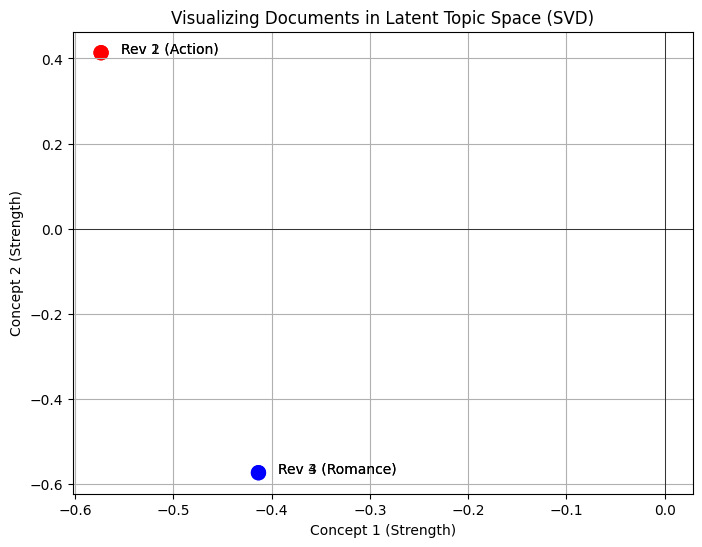

In [3]:
import matplotlib.pyplot as plt

# Re-run SVD to get coordinates for plotting
U, s, Vt = svd(X, full_matrices=False)

# The matrix U contains the coordinates of documents in the "Topic Space"
# We take the first 2 columns (Concept 1 and Concept 2)
coords = U[:, :2]

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=['red', 'red', 'blue', 'blue'], s=100)

# Label the points
labels = ["Rev 1 (Action)", "Rev 2 (Action)", "Rev 3 (Romance)", "Rev 4 (Romance)"]
for i, txt in enumerate(labels):
    plt.annotate(txt, (coords[i, 0]+0.02, coords[i, 1]))

plt.title("Visualizing Documents in Latent Topic Space (SVD)")
plt.xlabel("Concept 1 (Strength)")
plt.ylabel("Concept 2 (Strength)")
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.show()

---
### **Part 3: Numerical Stability & Precision**

**The Scenario:**
A junior engineer at StreamFlix accidentally introduced some random noise into our movie ratings database. We need to determine if this noise has fundamentally changed the structure of our data or if it's negligible.

This brings us to a crucial concept in Linear Algebra for Data Science: **Numerical Precision**. Mathematically, adding even a tiny amount of random noise to a low-rank matrix should make it "full rank." However, computers have limited precision (floating point), which affects how we compute ranks and eigenvalues in practice.

### **Perturbation Theory**

**We discussed this scenario in the class:**
Consider a matrix $A$ representing our movie data and a full-rank noise matrix $B$ (random integers from 1 to 100).
$$
A = \begin{bmatrix}
4 & 5 & 6 \\
1 & 2 & 3 \\
7 & 8 & 9
\end{bmatrix}
$$

We analyze the perturbed matrix $A' = A + \epsilon B$.

1.  **When $\epsilon = 1$:** What is the rank of $A'$?
2.  **When $\epsilon = 10^{-100}$:** What is the rank of $A'$?
3.  **Eigenvalues:** How many "non-zero" eigenvalues will $A'$ have in both cases? Comment on their magnitude.

*Think about the difference between "Theoretical Math" (infinite precision) and "Computer Math" (IEEE 754 floating point).*

### **Coding Part 3: The Epsilon Experiment**

**Question 5:**
We will simulate the scenario above. You will define the singular matrix $A$, generate a random noise matrix $B$, and observe how the **Rank** and **Eigenvalues** change as the noise factor $\epsilon$ gets smaller and smaller.

**Student Assignment:**
1.  Run the code for different values of `epsilon` (e.g., 1.0, 0.01, 1e-15, 1e-100).
2.  Observe at what point the computer can no longer "see" the noise.

In [4]:
import numpy as np
from numpy.linalg import matrix_rank, eigvals

# 1. Define Matrix A (Rank 2)
# Row 1 is the average of Row 2 and Row 3, making it linearly dependent.
A = np.array([
    [4, 5, 6],
    [1, 2, 3],
    [7, 8, 9]
])

# 2. Define Matrix B (Random Noise, Full Rank)
np.random.seed(42)
B = np.random.randint(1, 101, size=(3, 3))

print("Original Rank of A:", matrix_rank(A))
print("-" * 100)

#==================================================================================================================
# 3. Experiment with Epsilon
# TODO: Add different values of epsilon to this list to test precision
epsilons = [1.0, 0.01, 1e-10, 1e-100,10,1000,499,58,67,3.3306e-16]
#==================================================================================================================

for eps in epsilons:
    # Create the perturbed matrix
    A_prime = A + (eps * B)

    # Calculate properties
    r = matrix_rank(A_prime)
    e_vals = eigvals(A_prime)

    print(f"Epsilon: {eps}")
    print(f"  -> Calculated Rank: {r}")
    print(f"  -> Eigenvalues: {np.round(e_vals, 4)}")

    # Check if the smallest eigenvalue is effectively zero
    # (In Python, 'effectively zero' usually means < 1e-500)
    non_zeros = np.sum(np.abs(e_vals) > 1e-500)
    print(f"  -> Theoretically Non-Zero Eigenvalues: {non_zeros}")
    print("-" * 100)

Original Rank of A: 2
----------------------------------------------------------------------------------------------------
Epsilon: 1.0
  -> Calculated Rank: 3
  -> Eigenvalues: [185.502  -24.7541  42.2521]
  -> Theoretically Non-Zero Eigenvalues: 3
----------------------------------------------------------------------------------------------------
Epsilon: 0.01
  -> Calculated Rank: 3
  -> Eigenvalues: [17.2139+0.j     -0.167 +0.4567j -0.167 -0.4567j]
  -> Theoretically Non-Zero Eigenvalues: 3
----------------------------------------------------------------------------------------------------
Epsilon: 1e-10
  -> Calculated Rank: 3
  -> Eigenvalues: [15.5777 -0.     -0.5777]
  -> Theoretically Non-Zero Eigenvalues: 3
----------------------------------------------------------------------------------------------------
Epsilon: 1e-100
  -> Calculated Rank: 2
  -> Eigenvalues: [15.5777  0.     -0.5777]
  -> Theoretically Non-Zero Eigenvalues: 3
---------------------------------------------

Explaination for last part:
So, here We observe that at epsilon value 3.3306e-16 we can see the rank becomes 2 which means the computer can no longer see the noise and computer ignored the noise and thus reducing the rank of matrix form 3 to 2.